#### CareAssist Exploratory Data Analysis (EDA)
The following notebook contains EDA for ages 10-13, 14-17, and 18-21.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#### Data Preparation
- Get data from 2020-2024.
- Remove duplicates (StFCID + year combinations).
- Split data by age group (AgeAtLatRem) for EDA.

In [2]:
# load data and make column names lowercase
DATA_DIR = Path("/Users/courtneychen/Library/CloudStorage/Box-Box/capstone/data")

dfs = []
for year in range(2020, 2025):
    df = pd.read_parquet(DATA_DIR / f"afcars_{year}.parquet")
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
del dfs
data.columns = data.columns.str.lower()
data.head()


,fy,version,state,st,repdatyr,repdatmo,fipscode,recnumbr,sex,amiakn,...,entered,exited,served,iswaiting,istpr,agedout,raceethn,race,stfcid,year
0,2020,1,37,NC,2020,9,8,R99044225246,2.0,1.0,...,1,0,1,0,0,0,3,3,NCR99044225246,2020
1,2020,1,37,NC,2020,9,8,R99044231032,1.0,0.0,...,0,0,1,0,0,0,1,1,NCR99044231032,2020
2,2020,1,37,NC,2020,9,37051,R99044231063,1.0,0.0,...,0,0,1,0,0,0,99,99,NCR99044231063,2020
3,2020,1,37,NC,2020,9,8,R99044232374,2.0,0.0,...,1,0,1,0,0,0,1,1,NCR99044232374,2020
4,2020,1,37,NC,2020,9,8,R99044238028,1.0,0.0,...,0,0,1,0,0,0,1,1,NCR99044238028,2020


In [3]:
# remove duplicates
prev_len = len(data)

data = (
    data
    .drop_duplicates(subset=['stfcid', 'year'], keep='first')
    .reset_index(drop=True)
)

curr_len = len(data)

print(f"Removed {prev_len - curr_len} duplicate rows")

Removed 66 duplicate rows


In [4]:
# split data across age groups
early_teens = data[
    (data["ageatlatrem"] >= 10) &
    (data["ageatlatrem"] <= 13)
]

late_teens = data[
    (data["ageatlatrem"] >= 14) &
    (data["ageatlatrem"] <= 17)
]

adults = data[
    (data["ageatlatrem"] >= 18) &
    (data["ageatlatrem"] <= 21)
]

#### Statistics & Data Validity

Quick peep at null values.

In [5]:
print((data.isna().mean().sort_values(ascending=False) * 100).round(2).to_string())

previouslos    84.97
tprdate        81.12
dlstfcdt       80.57
tprdaddt       79.47
tprmomdt       78.47
dodtrndt       65.21
dodfcdt        64.45
fcctk2yr       60.79
rf2utod        54.69
rf2nhopi       54.25
rf2asian       54.25
rf2blkaa       54.21
rf2white       53.71
ctk2yr         52.35
rf2amakn       51.92
hofcctk2       39.58
ctkfamst       37.84
manrem         36.53
fcmntpay       36.45
ssiother       36.37
noa            36.33
xixmedcd       36.32
ivdchsup       36.32
fcctk1yr       29.49
rf1utod        29.25
othermed       27.76
emotdist       27.68
phydis         27.64
mr             27.62
vishear        27.52
rf1asian       27.46
rf1blkaa       27.36
rf1nhopi       26.89
rf1amakn       26.79
rf1white       26.78
pedrevdt       20.79
hofcctk1       20.45
ageadopt       12.27
abandmnt        7.70
prtsjail        7.52
nocope          6.74
fosfamst        6.43
ctk1yr          5.46
lifelos         4.73
clindis         3.29
aaparent        3.22
housing         2.22
everadpt     

There are quite a few rows with ages above 21 (likely dated entries).

In [6]:
data["ageatlatrem"].value_counts().sort_index()

ageatlatrem
0     577513
1     200926
2     179858
3     165310
4     152865
5     144633
6     138936
7     132183
8     123956
9     119539
10    115748
11    116993
12    122257
13    129733
14    131461
15    127183
16    106548
17     60144
18     21986
19      7179
20      3462
21       150
22        13
23         2
27         1
29         2
37         3
42         1
50         2
52         1
76         1
99       503
Name: count, dtype: int64

The majority of children were court-ordered to be removed from their homes, with a much smaller proportion of voluntary cases (and some undetermined).

In [7]:
data['manrem'].value_counts().sort_index()

manrem
1.0      58668
2.0    1745565
3.0      23148
Name: count, dtype: int64

The binary columns of interest contain only valid 0s and 1s.

In [8]:
binary_fields = [
    'phyabuse',
    'sexabuse',
    'neglect',
    'aaparent',
    'daparent',
    'aachild',
    'dachild',
    'childis',
    'chbehprb',
    'prtsdied',
    'prtsjail',
    'nocope',
    'abandmnt'
]

for field in binary_fields:
    bad_vals = data.loc[~data[field].isin([0, 1]), field].unique()
    if len(bad_vals) > 0:
        print(f"{field}: non-binary values found -> {bad_vals}")

phyabuse: non-binary values found -> [nan]
sexabuse: non-binary values found -> [nan]
neglect: non-binary values found -> [nan]
aaparent: non-binary values found -> [nan]
daparent: non-binary values found -> [nan]
aachild: non-binary values found -> [nan]
dachild: non-binary values found -> [nan]
childis: non-binary values found -> [nan]
chbehprb: non-binary values found -> [nan]
prtsdied: non-binary values found -> [nan]
prtsjail: non-binary values found -> [nan]
nocope: non-binary values found -> [nan]
abandmnt: non-binary values found -> [nan]


#### DOMAIN 2: Safety and Removal

In [17]:
abuse_cols = ["phyabuse", "sexabuse", "neglect"]

def plot_abuse_by_year(df, age_group_label):
    # get percent of foster children removed due to each abuse type by year
    summary = (
        df
        .groupby("fy")[abuse_cols]
        .mean()
        .reset_index()
    )

    years = summary["fy"].values
    x = np.arange(len(years))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, col in enumerate(abuse_cols):
        ax.bar(
            x + i * width,
            summary[col] * 100,
            width,
            label=col
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(years)
    ax.set_ylabel("Share of Foster Care Entries (%)")
    ax.set_xlabel("Fiscal Year")
    ax.set_title(f"Removals due to Maltreatment for Ages {age_group_label}")
    ax.legend(title="Abuse Type")

    plt.tight_layout()
    plt.show()

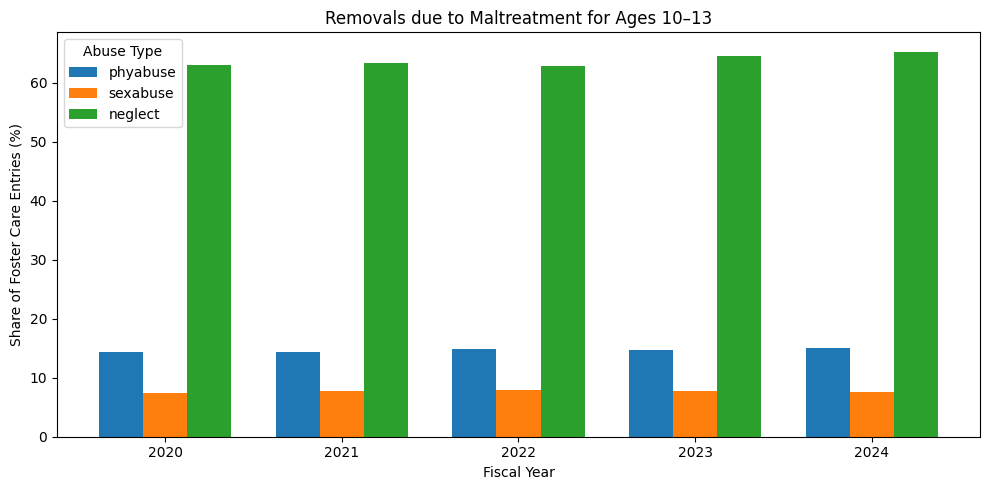

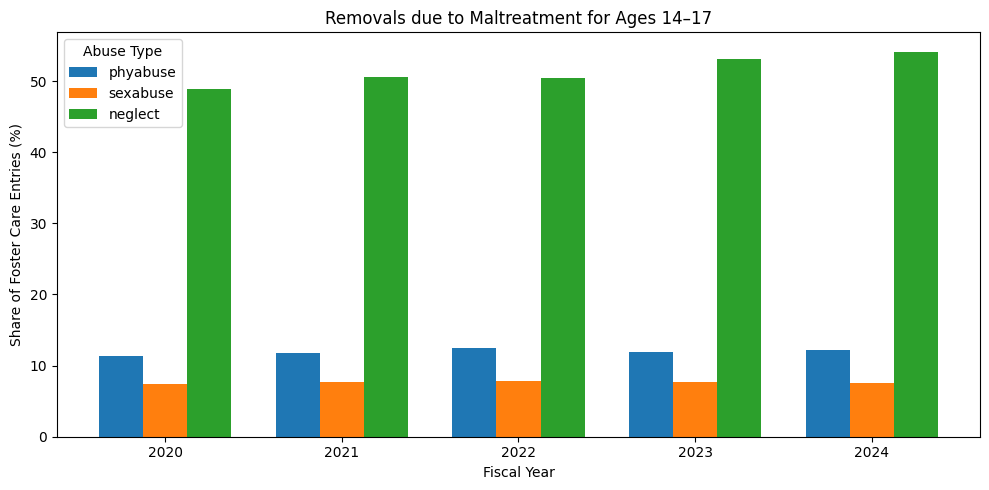

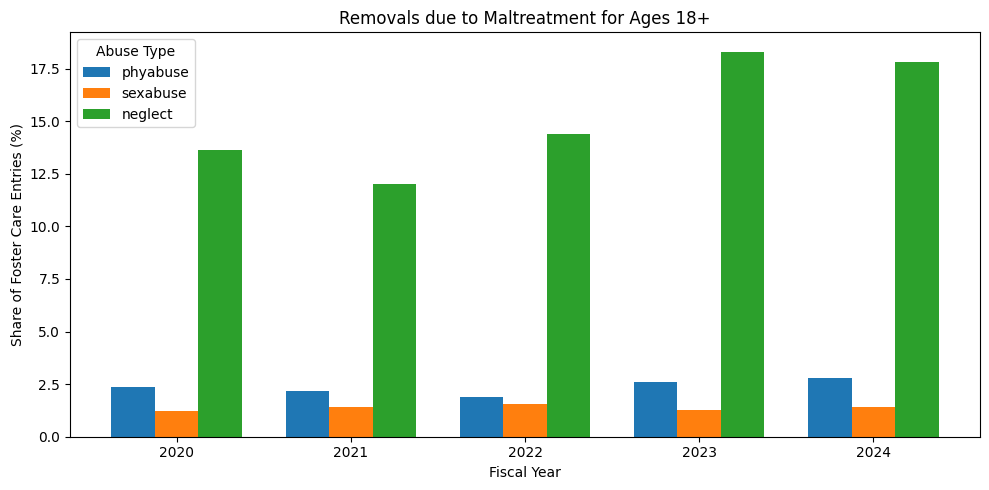

In [18]:
age_groups = [
    (early_teens, "10–13"),
    (late_teens, "14–17"),
    (adults, "18+")
]

for df, label in age_groups:
    plot_abuse_by_year(df, label)


#### DOMAIN 3: Health and Special Needs

In [19]:
disability_cols = ['clindis', 'emotdist', 'phydis', 'mr', 'vishear']

for col in disability_cols:
    s = data[col]
    print(
        col,
        "min:", s.min(),
        "max:", s.max(),
        "unique >1:", sorted(s[s > 1].unique())[:10]
    )

clindis min: 1.0 max: 3.0 unique >1: [2.0, 3.0]
emotdist min: 0.0 max: 1.0 unique >1: []
phydis min: 0.0 max: 1.0 unique >1: []
mr min: 0.0 max: 1.0 unique >1: []
vishear min: 0.0 max: 1.0 unique >1: []


Clinical disability contains values 1, 2, and 3 which need to be reformatted to binary for consistency.

In [24]:
print(data['clindis'].value_counts())

clindis
1.0    1436286
0.0     725091
Name: count, dtype: int64


In [ ]:
# make sure clindis is numeric
data["clindis"] = pd.to_numeric(data["clindis"], errors="coerce")

# drop "not determined"
data.loc[data["clindis"] == 3, "clindis"] = np.nan

# recode so no (1) becomes 0 and yes (2) becomes 1
data["clindis"] = data["clindis"].replace({1: 0, 2: 1})

# resplit data across age groups
early_teens = data[
    (data["ageatlatrem"] >= 10) &
    (data["ageatlatrem"] <= 13)
]

late_teens = data[
    (data["ageatlatrem"] >= 14) &
    (data["ageatlatrem"] <= 17)
]

adults = data[
    (data["ageatlatrem"] >= 18) &
    (data["ageatlatrem"] <= 21)
]

age_groups = [
    (early_teens, "10–13"),
    (late_teens, "14–17"),
    (adults, "18+")
]

In [23]:
data['clindis'].value_counts()

clindis
1.0    1436286
0.0     725091
Name: count, dtype: int64

In [30]:
def plot_indicators_by_year(
    df,
    age_group_label,
    indicator_cols,
    title_prefix="Indicator Prevalence"
):
    """
    Plots percent prevalence of indicator variables by year
    within a single age group.
    """

    plot_df = df.copy()

    # enforce binary indicator contract for plotting
    for col in indicator_cols:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
        plot_df.loc[~plot_df[col].isin([0, 1]), col] = np.nan

    summary = (
        plot_df
        .groupby("fy")[indicator_cols]
        .mean()
        .reset_index()
    )

    years = summary["fy"].values
    x = np.arange(len(years))
    width = 0.8 / len(indicator_cols)  # auto-scale width

    fig, ax = plt.subplots(figsize=(11, 5))

    for i, col in enumerate(indicator_cols):
        ax.bar(
            x + i * width,
            summary[col] * 100,
            width,
            label=col
        )

    ax.set_xticks(x + width * (len(indicator_cols) - 1) / 2)
    ax.set_xticklabels(years)
    ax.set_ylabel("Percent of Foster Care Entries (%)")
    ax.set_xlabel("Fiscal Year")
    ax.set_title(
        f"{title_prefix} (Ages {age_group_label})"
    )
    ax.legend(title="Indicator")

    plt.tight_layout()
    plt.show()

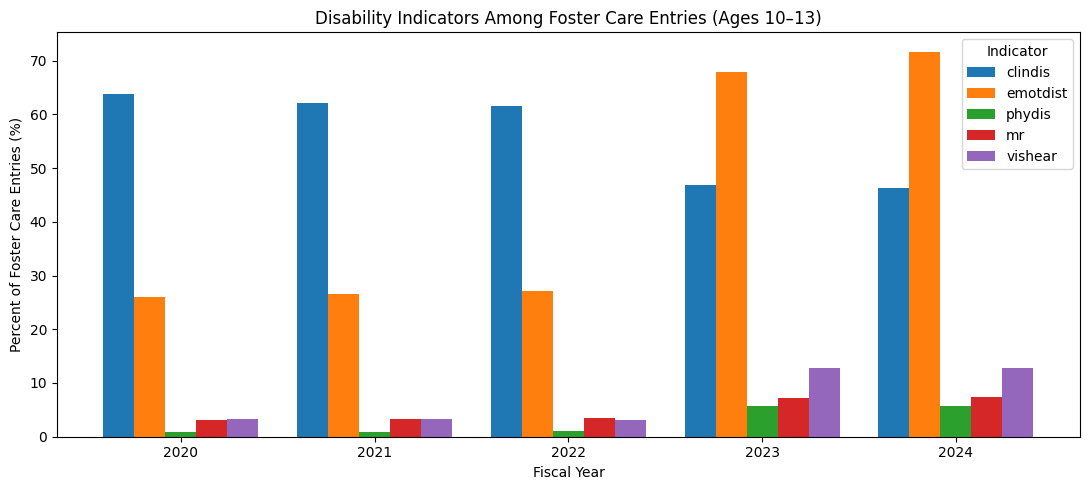

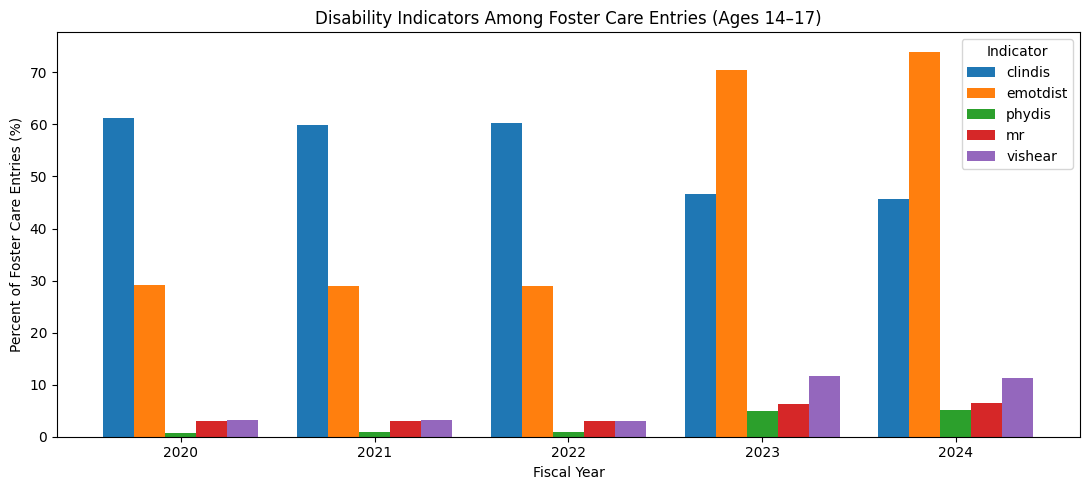

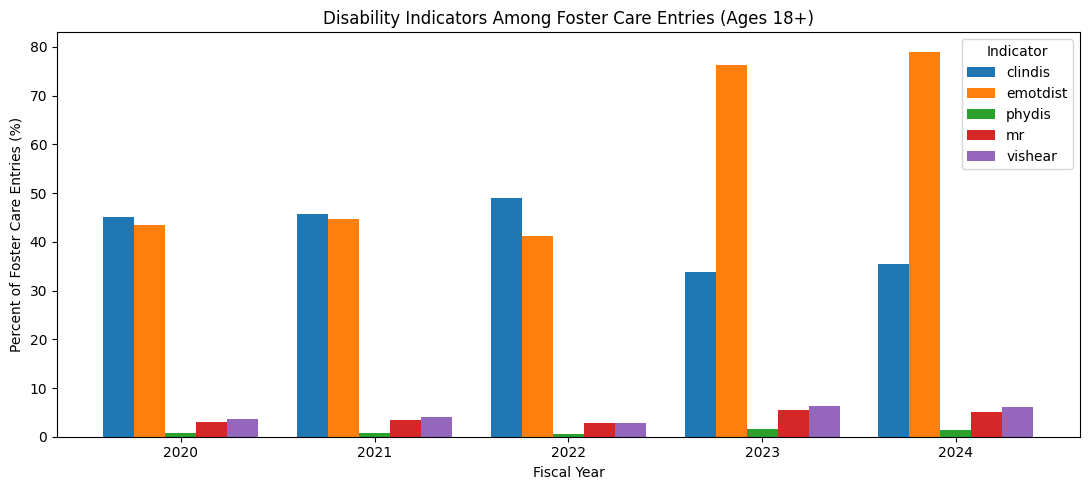

In [31]:
for df, label in age_groups:
    plot_indicators_by_year(df, label, disability_cols, "Disability Indicators Among Foster Care Entries")

#### DOMAIN 4: Legal and Permanency Complexity

In [26]:
legal_vars = ['prtsdied', 'istpr', 'iswaiting', 'relinqsh']

for col in disability_cols:
    s = data[col]
    print(
        col,
        "min:", s.min(),
        "max:", s.max(),
        "unique >1:", sorted(s[s > 1].unique())[:10]
    )

clindis min: 0.0 max: 1.0 unique >1: []
emotdist min: 0.0 max: 1.0 unique >1: []
phydis min: 0.0 max: 1.0 unique >1: []
mr min: 0.0 max: 1.0 unique >1: []
vishear min: 0.0 max: 1.0 unique >1: []


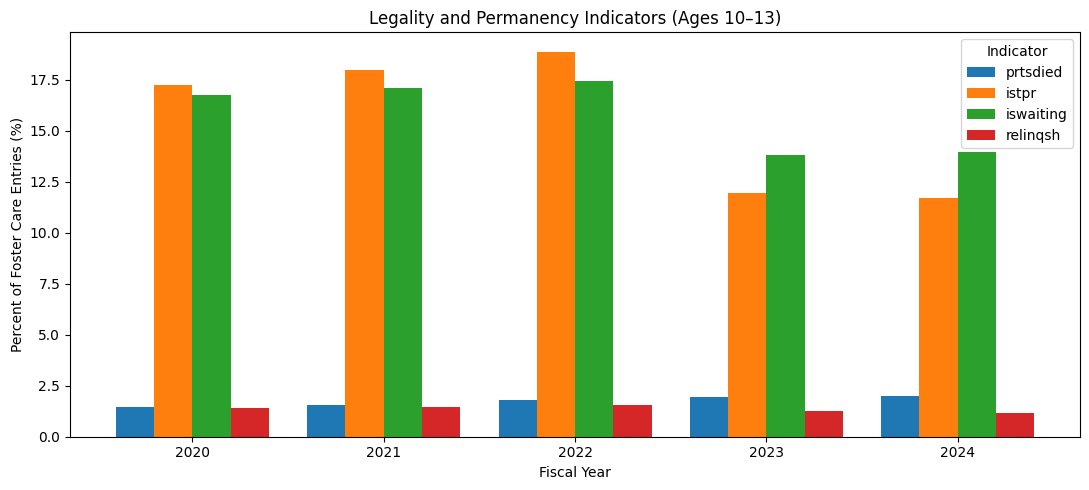

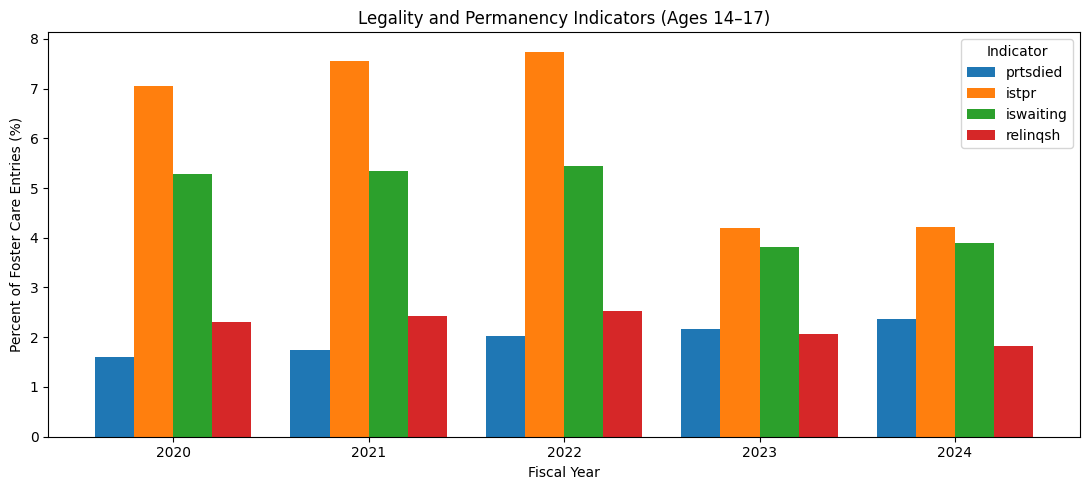

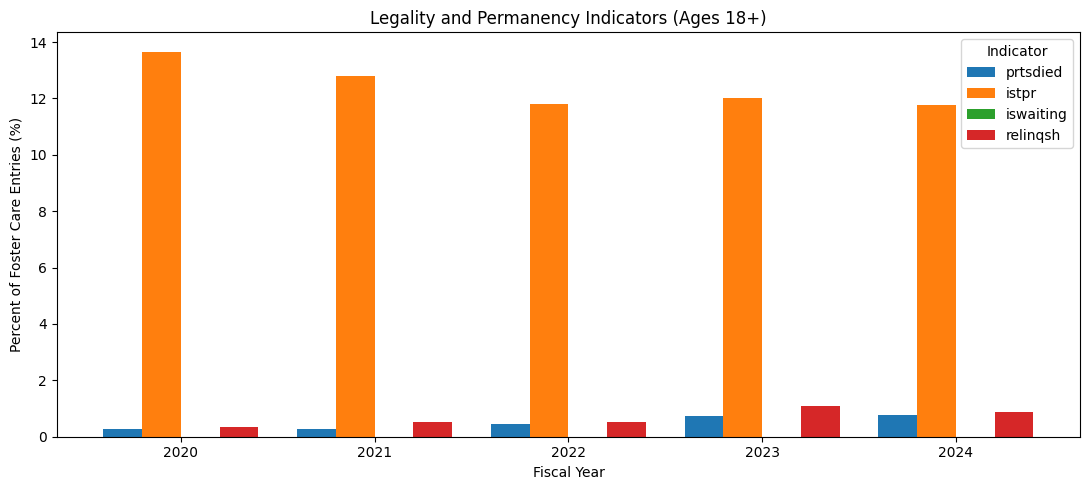

In [28]:
for df, label in age_groups:
    plot_indicators_by_year(df, label, legal_vars, title_prefix='Legality and Permanency Indicators')

#### DOMAIN 5: Age-Related Vulnerability

These values are slightly lower than Helin's because I didn't include 2019 data.

In [33]:
print("\n" + "="*80)
print("DOMAIN 5: AGE-RELATED VULNERABILITY")
print("="*80)

# Age at removal statistics (already analyzed above)
# Focus on aged out analysis

if 'agedout' in data.columns:
    for age_df, age_name in age_groups:
        aged_out_count = (age_df['agedout'] == 1).sum()
        print(f"\nAge Group {age_name}:")
        print(f"  Aged out: {aged_out_count:,} ({aged_out_count/len(age_df)*100:.2f}%)")


DOMAIN 5: AGE-RELATED VULNERABILITY

Age Group 10–13:
  Aged out: 12,138 (2.50%)

Age Group 14–17:
  Aged out: 48,648 (11.44%)

Age Group 18+:
  Aged out: 7,836 (23.91%)


#### DOMAIN 6: Discharge Reasons Analysis

In [ ]:
data['disreasn'].value_counts()

disreasn
99    1859239
1      469829
3      265775
5      113035
4       92275
2       62769
6       11254
7        2934
8        1982
Name: count, dtype: int64

In [39]:
discharge_group_map = {
    1: "Living with kin",      # Reunified with parent/caretaker
    2: "Living with kin",      # Living with other relative(s)
    3: "Living with other",   # Adoption
    4: "Aged out",            # Emancipation
    5: "Living with other",   # Guardianship
    6: "Transfer out",        # Transfer to another agency
    7: "Runaway",
    8: "Death of child"
}
data = data[data['disreasn'] != 99]
data = data[data['disreasn'] != 0]
data["discharge_group"] = data["disreasn"].map(discharge_group_map)

# resplit data across age groups
early_teens = data[
    (data["ageatlatrem"] >= 10) &
    (data["ageatlatrem"] <= 13)
]

late_teens = data[
    (data["ageatlatrem"] >= 14) &
    (data["ageatlatrem"] <= 17)
]

adults = data[
    (data["ageatlatrem"] >= 18) &
    (data["ageatlatrem"] <= 21)
]

age_groups = [
    (early_teens, "10–13"),
    (late_teens, "14–17"),
    (adults, "18+")
]

In [40]:
data['discharge_group'].value_counts()

discharge_group
Living with kin      532598
Living with other    378810
Aged out              92275
Transfer out          11254
Runaway                2934
Death of child         1982
Name: count, dtype: int64

Will likely convert this into a "Successful vs. Other Outcomes" Stacked Bar.

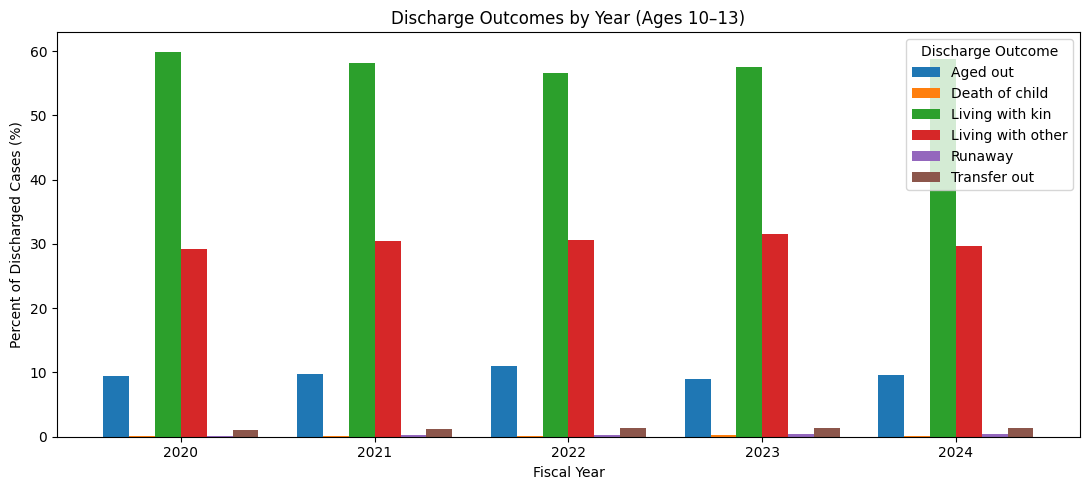

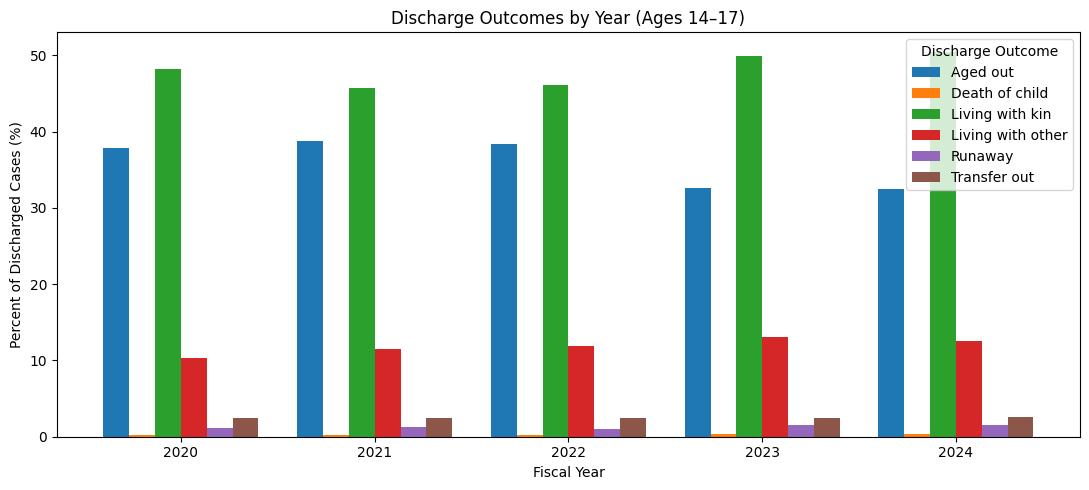

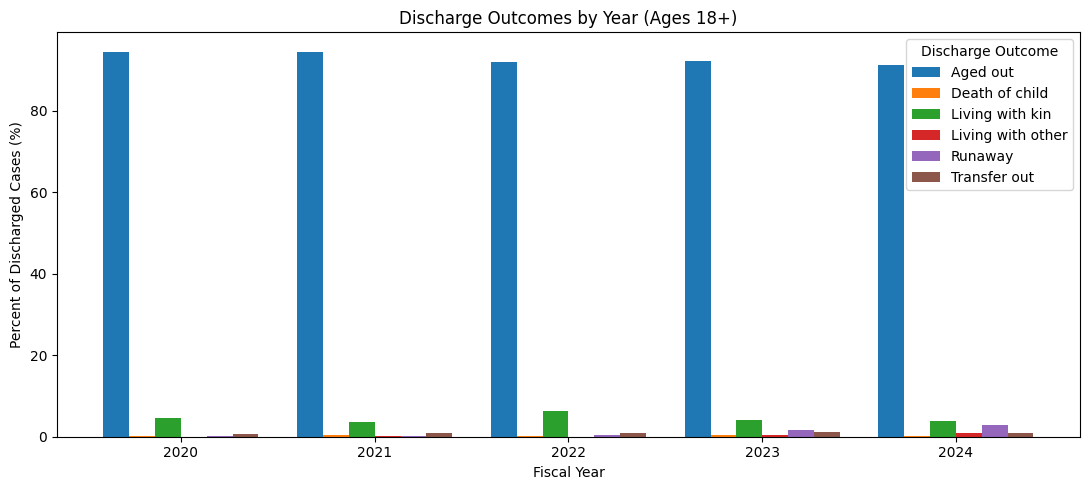

In [43]:
def plot_categorical_by_year(
    df,
    age_group_label,
    category_col,
    title_prefix
):
    # drop rows with missing category (e.g., Not Applicable)
    plot_df = df.dropna(subset=[category_col]).copy()

    # get all years and categories up front
    years = sorted(plot_df["fy"].unique())
    categories = sorted(plot_df[category_col].unique())

    # count per year and category
    summary = (
        plot_df
        .groupby(["fy", category_col])
        .size()
        .reset_index(name="count")
    )

    # convert to percent within year
    summary["percent"] = (
        summary["count"] /
        summary.groupby("fy")["count"].transform("sum")
    ) * 100

    # 🔑 reindex so every (year, category) exists
    summary = (
        summary
        .set_index(["fy", category_col])
        .reindex(
            pd.MultiIndex.from_product(
                [years, categories],
                names=["fy", category_col]
            ),
            fill_value=0
        )
        .reset_index()
    )

    x = np.arange(len(years))
    width = 0.8 / len(categories)

    fig, ax = plt.subplots(figsize=(11, 5))

    for i, cat in enumerate(categories):
        sub = summary[summary[category_col] == cat]
        ax.bar(
            x + i * width,
            sub["percent"],
            width,
            label=cat
        )

    ax.set_xticks(x + width * (len(categories) - 1) / 2)
    ax.set_xticklabels(years)
    ax.set_ylabel("Percent of Discharged Cases (%)")
    ax.set_xlabel("Fiscal Year")
    ax.set_title(f"{title_prefix} by Year (Ages {age_group_label})")
    ax.legend(title="Discharge Outcome")

    plt.tight_layout()
    plt.show()

for df, label in age_groups:
    plot_categorical_by_year(
        df,
        label,
        category_col="discharge_group",
        title_prefix="Discharge Outcomes"
    )